Proyek ini mengimplementasikan **Algoritma Genetika (Genetic Algorithm)** untuk menyelesaikan masalah optimasi fungsi matematika (*Function Optimization*) menggunakan metode seleksi berbasis peringkat (*Rank-Based Selection*).

### Studi Kasus & Konsep Dasar:
* **Cerita:** Kita ingin mencari nilai variabel $x$ terbaik untuk memaksimalkan hasil dari sebuah fungsi matematika pada rentang nilai tertentu (mencari titik puncak tertinggi pada kurva grafik).
* **Tujuan GA:** Mengoptimalkan nilai $x$ agar menghasilkan nilai output fungsi $f(x)$ setinggi mungkin.
* **Binary Encoding & Rank-Based Selection:** Solusi direpresentasikan sebagai string biner yang diterjemahkan (*decode*) menjadi angka riil. Menggunakan *Rank-Based Selection* di mana peluang terpilih didasarkan pada urutan peringkat fitness (dari terburuk hingga terbaik), sehingga persaingan antar individu lebih adil dan mencegah dominasi prematur.

In [1]:
import random
import matplotlib.pyplot as plt

In [2]:
pop_size = 14
generations = 30
chromo_length = 8  # Panjang bit biner untuk merepresentasikan nilai x
CR = 0.8           # Crossover rate
MR = 0.05          # Mutation rate

# Rentang nilai x yang ingin dioptimasi (antara 0 sampai 10)
x_min = 0.0
x_max = 10.0

### Fungsi konversi biner ke desimal / nilai asli X

In [3]:
function_mapping_binary_to_decimal = lambda chromosome: int("".join(map(str, chromosome)), 2)

In [4]:
def decode_chromosome(chromosome):
    dec_val = function_mapping_binary_to_decimal(chromosome)
    max_dec = (2 ** chromo_length) - 1
    x = x_min + (dec_val / max_dec) * (x_max - x_min)
    return x

### Fitness

In [5]:
def calculate_fitness(chromosome):
    x = decode_chromosome(chromosome)
    fitness = - (x-5)**2 + 25
    return max(fitness, 0.001)

### Populasi awal

In [6]:
def create_chromosome():
    return [random.randint(0, 1) for _ in range(chromo_length)]

population = [create_chromosome() for _ in range(pop_size)]
print(population)

[[1, 0, 0, 0, 1, 1, 1, 0], [0, 1, 0, 0, 0, 0, 1, 1], [0, 1, 0, 1, 1, 1, 1, 1], [1, 1, 1, 0, 1, 1, 0, 1], [0, 0, 0, 0, 0, 1, 1, 0], [0, 0, 1, 0, 1, 0, 0, 0], [0, 1, 1, 0, 0, 1, 1, 0], [0, 1, 1, 0, 0, 1, 1, 0], [0, 0, 1, 1, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0, 0, 1], [0, 0, 0, 0, 1, 1, 0, 0], [1, 0, 1, 1, 0, 1, 1, 0], [0, 0, 0, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 1, 1, 1]]


### Rank based selection

In [7]:
def rank_based_selection(population, fitnesses):
    indexed_fitness = list(enumerate(fitnesses))
    indexed_fitness.sort(key=lambda x:x[1])

    ranks = list(range(1, len(population) + 1))
    total_rank = sum(ranks)

    cumulative_probs = []
    current_sum = 0
    for r in ranks:
        current_sum += (r / total_rank)
        cumulative_probs.append(current_sum)

    pick = random.random()
    for i, prob in enumerate(cumulative_probs):
        if pick <= prob:
            original_idx = indexed_fitness[i][0]
            return population[original_idx].copy()
    return population[indexed_fitness[-1][0].copy()]

### crossover

In [8]:
def crossover(parent1, parent2):
    if random.random() < CR:
        cut = random.randint(1, chromo_length - 1)
        child1 = parent1[:cut] + parent2[cut:]
        child2 = parent2[:cut] + parent1[cut:]
        return child1, child2
    return parent1.copy(), parent2.copy()

### Mutation

In [9]:
def mutate(chromosome):
    mutated = chromosome.copy()
    for i in range(len(mutated)):
        if random.random() < MR:
            mutated[i] = 1 if mutated[i] == 0 else 0
        return mutated

### Main

In [10]:
best_fitness_history = []
best_x_ever = None
best_fitness_ever = -1
best_chromosome_ever = None

for gen in range(generations):
    fitnesses = [calculate_fitness(ind) for ind in population]

    max_fit_idx = fitnesses.index(max(fitnesses))
    current_best_fit = fitnesses[max_fit_idx]
    current_best_ind = population[max_fit_idx]

    if current_best_fit > best_fitness_ever:
        best_fitness_ever = current_best_fit
        best_chromosome_ever = current_best_ind.copy()
        best_x_ever = decode_chromosome(current_best_ind)

    best_fitness_history.append(current_best_fit)

    new_population = [current_best_ind.copy()]

    while len(new_population) < pop_size:
        p1 = rank_based_selection(population, fitnesses)
        p2 = rank_based_selection(population, fitnesses)

        c1, c2 = crossover(p1, p2)
        c1 = mutate(c1)
        c2 = mutate(c2)

        new_population.append(c1)
        if len(new_population) < pop_size:
            new_population.append(c2)

    population = new_population

### hasil akhir

In [11]:
print("HASIL AKHIR FUNCTION OPTIMIZATION")
print(f"Nilai Fitness Maksimal Ditemukan: {best_fitness_ever:.4f}")
print(f"Kromosom Terbaik (Biner): {best_chromosome_ever}")
print(f"Nilai Variabel x Optimal: {best_x_ever:.4f}")

HASIL AKHIR FUNCTION OPTIMIZATION
Nilai Fitness Maksimal Ditemukan: 24.9689
Kromosom Terbaik (Biner): [1, 0, 0, 0, 0, 1, 0, 0]
Nilai Variabel x Optimal: 5.1765


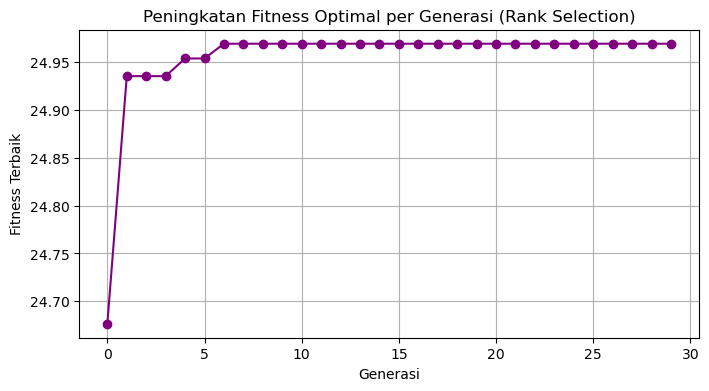

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(best_fitness_history, marker='o', color='purple')
plt.title("Peningkatan Fitness Optimal per Generasi (Rank Selection)")
plt.xlabel("Generasi")
plt.ylabel("Fitness Terbaik")
plt.grid(True)
plt.show()